# Kalshi microstructure — implied win probability

**What this shows.** For a settled NBA game, the Kalshi prediction market's minute-by-minute
**implied win probability** (the midpoint of the yes bid/ask, in cents ≈ %), and how it converged
to the final result. Reads the **2025-26 archive**, so it works year-round — no live game needed.

**Quota cost.** ~700 records (one market's 1-minute candles + a few event/market rows).
Under a ~10k budget.

> **Setup.** Install deps (`pip install -r requirements.txt` plus the editable SDK — see the
> [README](../README.md)) and export your key once:
>
> ```bash
> export STAT_API_KEY=sdb_xxxxxxxx_...
> ```
>
> The client reads `STAT_API_KEY` from the environment. To run against a local mirror instead of
> production, also set `STAT_API_BASE_URL` (e.g. `http://localhost:3399`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statapi import StatApi

api = StatApi()

COMPETITION_ID = 5845476   # NBA 2025-26: Charlotte at Sacramento, 2026-03-11
LEAGUE = "nba"
PERIOD = 60                # candle width in seconds (60 = 1-minute bars)

## 1 · Find the game's markets

Kalshi groups markets into *events*. One sporting game can span several events (winner, total
points, spread). We resolve them by `league_code` + `competition_id`, then keep the **game-winner**
event (`contract_type == "gw"`).

In [2]:
events = list(api.kalshi.events.iter(league_code=LEAGUE, competition_id=COMPETITION_ID))
print("events for this game:")
for e in events:
    print(f"  {e['id']}  {e['title']}")

gw_markets = None
for e in events:
    ms = [m for m in api.kalshi.markets.iter(event_id=e["id"]) if m.get("contract_type") == "gw"]
    if ms:
        gw_markets = ms
        break

pd.DataFrame(
    [(m["id"], m["ticker"], m["result"], m["settlement_value"]) for m in gw_markets],
    columns=["market_id", "ticker", "result", "settled_at_cents"],
)

events for this game:
  46988  Charlotte at Sacramento: Total Points
  46981  Sacramento wins by over 3.5 Points?
  47816  Charlotte at Sacramento Winner?


,market_id,ticker,result,settled_at_cents
0,410381,KXNBAGAME-26MAR11CHASAC-CHA,yes,100
1,410380,KXNBAGAME-26MAR11CHASAC-SAC,no,0


## 2 · The winning contract

Each team has a yes/no "does this team win" contract. The one that settled `yes` (100¢) is the
winner; its implied-probability curve should climb toward 100 as the game is decided.

In [3]:
winner = next(m for m in gw_markets if m["result"] == "yes")
print("winning contract:", winner["ticker"], "settled", winner["settlement_value"], "cents")

winning contract: KXNBAGAME-26MAR11CHASAC-CHA settled 100 cents


## 3 · Pull the 1-minute candles

In [4]:
candles = list(api.kalshi.candles.iter(market_id=winner["id"], period_interval=PERIOD))
cd = pd.DataFrame(candles).dropna(subset=["yes_bid_close", "yes_ask_close"])
cd["ts"] = pd.to_datetime(cd["end_period_ts"], unit="s", utc=True).dt.tz_convert("US/Eastern")
cd = cd.sort_values("ts").reset_index(drop=True)
# implied win prob = midpoint of the yes bid/ask (cents == %)
cd["implied_wp"] = (cd["yes_bid_close"] + cd["yes_ask_close"]) / 2
print(f"{len(cd)} candles, {cd['ts'].min():%Y-%m-%d %H:%M} → {cd['ts'].max():%H:%M} ET")
cd[["ts", "yes_bid_close", "yes_ask_close", "implied_wp", "volume"]].head()

636 candles, 2026-03-11 10:22 → 00:34 ET


,ts,yes_bid_close,yes_ask_close,implied_wp,volume
0,2026-03-11 10:22:00-04:00,81,87,84.0,0
1,2026-03-11 10:25:00-04:00,83,87,85.0,0
2,2026-03-11 10:27:00-04:00,83,87,85.0,0
3,2026-03-11 10:31:00-04:00,85,87,86.0,0
4,2026-03-11 10:32:00-04:00,85,87,86.0,39


## 4 · Implied win probability over time

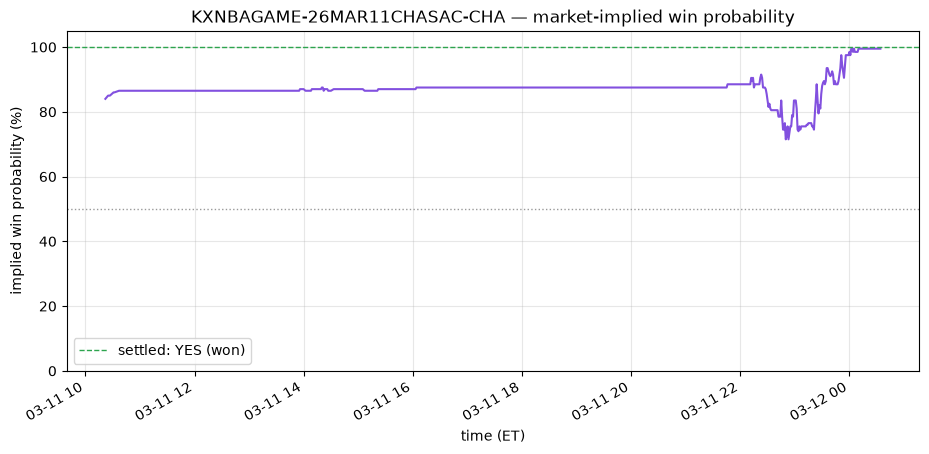

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cd["ts"], cd["implied_wp"], color="#8250df", lw=1.5)
ax.axhline(100, color="#2da44e", ls="--", lw=1, label="settled: YES (won)")
ax.axhline(50, color="#999", ls=":", lw=1)
ax.set_ylim(0, 105)
ax.set_ylabel("implied win probability (%)")
ax.set_xlabel("time (ET)")
ax.set_title(f"{winner['ticker']} — market-implied win probability")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

The curve is a live read on the crowd's belief that this team wins, second-guessed on every
possession, and it resolves at 100¢ when the result is final — exactly matching the box score.

## Quota used

In [6]:
q = api.kalshi.candles.list(market_id=winner["id"], period_interval=PERIOD, limit=1).quota
print(f"Records remaining this month: {q.remaining:,} of {q.limit:,}")

Records remaining this month: 33,967 of 50,000
